# 03 — Model Training & Evaluation
**Healthcare Recommendation System — Milestone 3**

Explores all three trained models via MLflow:  
- Collaborative Filtering (ALS)
- Content-Based (Cosine Similarity)
- Hybrid (XGBoost)

Compares metrics, inspects recommendations, and visualises results.

**Prerequisites:** Run `make train-all` before opening this notebook.

```bash
pip install mlflow clickhouse-connect pandas matplotlib seaborn
make explore-models
# or: jupyter notebook notebooks/03_model_training.ipynb
```

In [2]:
import warnings
warnings.filterwarnings('ignore')

import mlflow
from mlflow.tracking import MlflowClient
import clickhouse_connect
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import json

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
%matplotlib inline

# MLflow connection
MLFLOW_URI      = 'http://localhost:5001'
EXPERIMENT_NAME = 'healthcare-recommendations'

mlflow.set_tracking_uri(MLFLOW_URI)
mlf_client = MlflowClient(tracking_uri=MLFLOW_URI)

# ClickHouse connection
ch_client = clickhouse_connect.get_client(
    host='localhost', port=8123,
    database='healthcare',
    username='healthcare_user',
    password='ch_secret_2026',
    compress=False,
)

def q(sql):
    return ch_client.query_df(sql)

print('MLflow URI:  ', MLFLOW_URI)
print('ClickHouse:  connected')

# Verify experiment exists
exp = mlf_client.get_experiment_by_name(EXPERIMENT_NAME)
assert exp is not None, f'Experiment "{EXPERIMENT_NAME}" not found — run make train-all first'
print(f'Experiment:  {EXPERIMENT_NAME}  (ID: {exp.experiment_id})')

MLflow URI:   http://localhost:5001
ClickHouse:  connected
Experiment:  healthcare-recommendations  (ID: 1)


## 1. MLflow runs overview

In [3]:
# Fetch all finished runs
runs = mlf_client.search_runs(
    experiment_ids=[exp.experiment_id],
    filter_string="attributes.status = 'FINISHED'",
    order_by=['attribute.start_time DESC'],
)

print(f'Total finished runs: {len(runs)}')

rows = []
for run in runs:
    rows.append({
        'run_name':    run.data.tags.get('mlflow.runName', ''),
        'model_type':  run.data.params.get('model_type', ''),
        'run_id':      run.info.run_id[:8] + '...',
        'start_time':  pd.to_datetime(run.info.start_time, unit='ms').strftime('%Y-%m-%d %H:%M'),
        **{k: round(v, 4) for k, v in run.data.metrics.items()
           if k not in ['training_complete']},
    })

df_runs = pd.DataFrame(rows)
df_runs

Total finished runs: 4


,run_name,model_type,run_id,start_time,best_normalised_score,hybrid_xgboost_score,content_based_score,auc_roc,average_precision,importance_sim_med_count,importance_med_prevalence,importance_num_medications,importance_has_coronary_disease,importance_gender_encoded,precision_at_k,recall_at_k,ndcg_at_k,n_test_patients,rmse,n_patients_with_recommendations
0,evaluation_summary,,b2c5500a...,2026-04-29 11:22,0.9796,0.9796,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,hybrid_xgboost,hybrid_xgboost,57af36fa...,2026-04-29 11:21,NaN,NaN,NaN,0.9796,0.9545,0.7816,0.0763,0.0388,0.0258,0.0143,NaN,NaN,NaN,NaN,NaN,NaN
2,content_based,content_based_cosine_similarity,76990394...,2026-04-29 11:17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,"2,252.0000",NaN,NaN
3,collaborative_filtering,,505393c0...,2026-04-29 11:17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.7695,"10,928.0000"


In [4]:
# Get latest run per model type (excluding evaluation_summary)
MODEL_TYPES = {
    'collaborative_filtering': 'ALS Collaborative Filtering',
    'content_based_cosine_similarity': 'Content-Based (Cosine)',
    'hybrid_xgboost': 'Hybrid XGBoost',
}

latest_runs = {}
for run in runs:
    model_type = run.data.params.get('model_type', '')
    for key in MODEL_TYPES:
        if key in model_type or model_type in key:
            if key not in latest_runs:
                latest_runs[key] = run
            break

print('Latest runs per model:')
for key, run in latest_runs.items():
    print(f'  {MODEL_TYPES[key]:<35} run_id={run.info.run_id[:12]}...')

Latest runs per model:
  ALS Collaborative Filtering         run_id=b2c5500afc49...
  Hybrid XGBoost                      run_id=57af36fab121...
  Content-Based (Cosine)              run_id=769903947ea9...


## 2. Metrics comparison

In [5]:
# Build comparison table
comparison = []

for key, run in latest_runs.items():
    metrics = run.data.metrics
    params  = run.data.params
    row = {
        'Model': MODEL_TYPES.get(key, key),
        'RMSE':              metrics.get('rmse',              None),
        'Precision@10':      metrics.get('precision_at_k',    None),
        'Recall@10':         metrics.get('recall_at_k',       None),
        'NDCG@10':           metrics.get('ndcg_at_k',         None),
        'AUC-ROC':           metrics.get('auc_roc',           None),
        'Avg Precision':     metrics.get('average_precision', None),
        'N patients':        params.get('n_patients',         ''),
        'N interactions':    metrics.get('n_interactions',    ''),
    }
    comparison.append(row)

df_cmp = pd.DataFrame(comparison).set_index('Model')

# Style: highlight best value per metric
float_cols = [c for c in df_cmp.columns if df_cmp[c].dtype == float]
print('Model Metrics Comparison:')
display(df_cmp.style
    .format('{:.4f}', subset=float_cols, na_rep='—')
    .highlight_max(subset=['Precision@10','Recall@10','NDCG@10','AUC-ROC','Avg Precision'],
                   color='#d4edda', axis=0)
    .highlight_min(subset=['RMSE'], color='#d4edda', axis=0)
)

Model Metrics Comparison:


,RMSE,Precision@10,Recall@10,NDCG@10,AUC-ROC,Avg Precision,N patients,N interactions
Model,,,,,,,,
ALS Collaborative Filtering,None,—,—,—,—,—,,
Hybrid XGBoost,None,—,—,—,0.9796,0.9545,,
Content-Based (Cosine),None,0.0000,0.0000,0.0000,—,—,11679,


ValueError: operands could not be broadcast together with remapped shapes [original->remapped]: (0,)  and requested shape (3,)

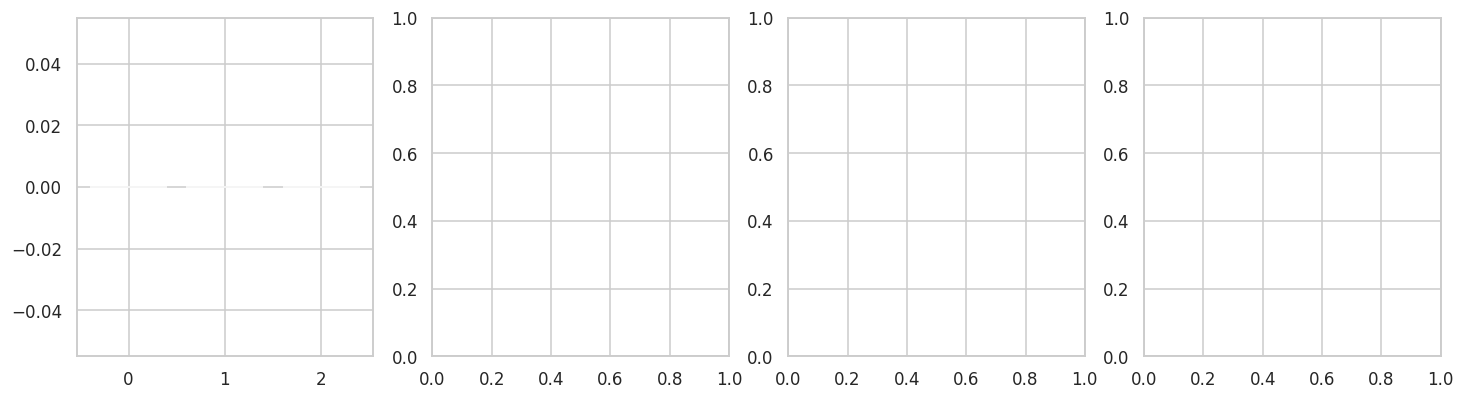

In [6]:
# Radar / bar chart comparison
plot_metrics = {
    'Precision@10':  'precision_at_k',
    'Recall@10':     'recall_at_k',
    'NDCG@10':       'ndcg_at_k',
    'AUC-ROC':       'auc_roc',
}

plot_data = {}
for key, run in latest_runs.items():
    plot_data[MODEL_TYPES[key]] = {
        label: run.data.metrics.get(metric_key, 0)
        for label, metric_key in plot_metrics.items()
    }

df_plot = pd.DataFrame(plot_data).T.fillna(0)

fig, axes = plt.subplots(1, len(plot_metrics), figsize=(16, 4))

colors = sns.color_palette('muted', len(plot_data))

for ax, metric in zip(axes, plot_metrics.keys()):
    values = df_plot[metric]
    bars = ax.bar(range(len(values)), values.values,
                  color=colors, tick_label=[])
    ax.set_title(metric)
    ax.set_ylim(0, max(values.max() * 1.25, 0.1))
    ax.set_xticks(range(len(values)))
    ax.set_xticklabels(
        [n.replace(' (', '\n(') for n in values.index],
        fontsize=8, rotation=10
    )
    for bar, val in zip(bars, values):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.002,
                    f'{val:.4f}', ha='center', fontsize=8)

plt.suptitle('Model Metrics Comparison', fontsize=13)
plt.tight_layout()
plt.show()

## 3. ALS — Collaborative Filtering deep dive

In [7]:
als_run = latest_runs.get('collaborative_filtering')

if als_run:
    print('ALS run parameters:')
    for k, v in als_run.data.params.items():
        print(f'  {k:<35} {v}')
    print()
    print('ALS run metrics:')
    for k, v in als_run.data.metrics.items():
        if k != 'training_complete':
            print(f'  {k:<35} {v:.4f}')
else:
    print('ALS run not found — run make run-als first')

ALS run parameters:
  best_model_type                     hybrid_xgboost
  best_model_name                     healthcare-hybrid-xgboost
  best_model_version                  1
  best_run_id                         57af36fab12141fb9b6f9f383cb4eb5b

ALS run metrics:
  best_normalised_score               0.9796
  hybrid_xgboost_score                0.9796
  content_based_score                 0.0000


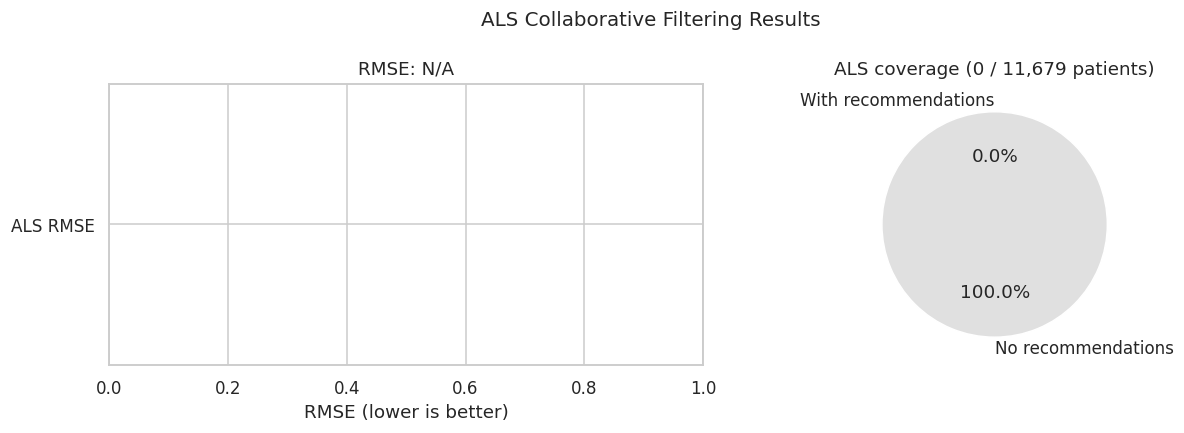

In [8]:
if als_run:
    rmse = als_run.data.metrics.get('rmse', None)
    n_recs = als_run.data.metrics.get('n_patients_with_recommendations', None)
    n_interactions = als_run.data.metrics.get('n_interactions', None)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # RMSE context
    axes[0].barh(['ALS RMSE'], [rmse or 0], color='steelblue')
    axes[0].set_xlim(0, max((rmse or 0) * 1.5, 1))
    axes[0].set_title(f'ALS Test RMSE: {rmse:.4f}' if rmse else 'RMSE: N/A')
    axes[0].set_xlabel('RMSE (lower is better)')
    if rmse:
        axes[0].text(rmse + 0.01, 0, f'{rmse:.4f}', va='center')

    # Coverage
    total_pts = ch_client.query('SELECT count() FROM healthcare.patient_features').result_rows[0][0]
    axes[1].pie(
        [n_recs or 0, total_pts - (n_recs or 0)],
        labels=['With recommendations', 'No recommendations'],
        autopct='%1.1f%%',
        colors=['steelblue', '#e0e0e0'],
        startangle=90,
    )
    axes[1].set_title(f'ALS coverage ({int(n_recs or 0):,} / {total_pts:,} patients)')

    plt.suptitle('ALS Collaborative Filtering Results', fontsize=13)
    plt.tight_layout()
    plt.show()

## 4. Content-Based deep dive

In [9]:
cb_run = latest_runs.get('content_based_cosine_similarity')

if cb_run:
    print('Content-Based run parameters:')
    for k, v in cb_run.data.params.items():
        print(f'  {k:<30} {v}')
    print()
    print('Content-Based metrics:')
    for k, v in cb_run.data.metrics.items():
        if k != 'training_complete':
            print(f'  {k:<30} {v:.4f}')
else:
    print('Content-Based run not found — run make run-content-based first')

Content-Based run parameters:
  model_type                     content_based_cosine_similarity
  top_k                          10
  n_similar                      20
  n_patients                     11679
  feature_dim                    111
  test_ratio                     0.2

Content-Based metrics:
  precision_at_k                 0.0000
  recall_at_k                    0.0000
  ndcg_at_k                      0.0000
  n_test_patients                2252.0000


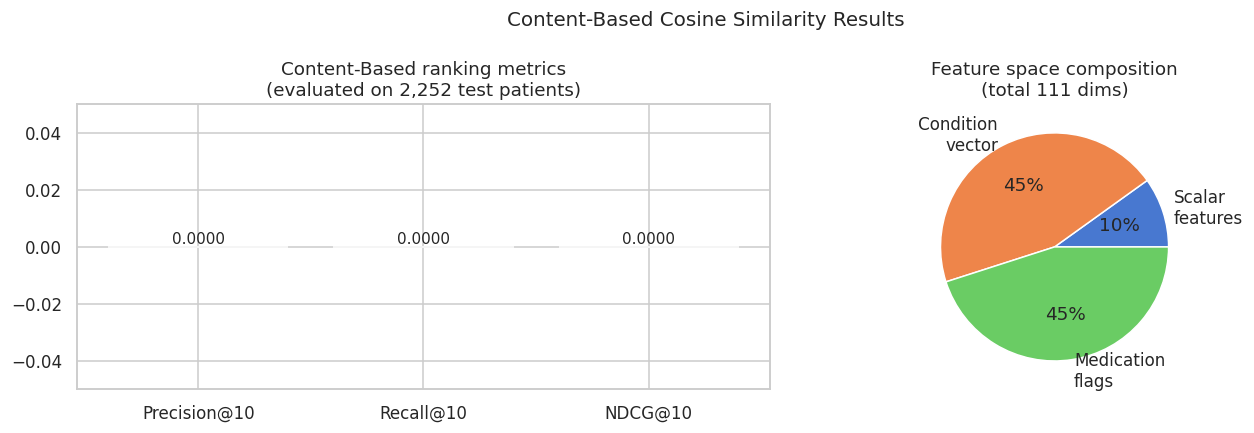

In [10]:
if cb_run:
    prec = cb_run.data.metrics.get('precision_at_k', 0)
    rec  = cb_run.data.metrics.get('recall_at_k',    0)
    ndcg = cb_run.data.metrics.get('ndcg_at_k',      0)
    n_test = int(cb_run.data.metrics.get('n_test_patients', 0))
    feat_dim = int(cb_run.data.params.get('feature_dim', 0))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Ranking metrics
    metrics_vals = {'Precision@10': prec, 'Recall@10': rec, 'NDCG@10': ndcg}
    bars = axes[0].bar(metrics_vals.keys(), metrics_vals.values(),
                       color=sns.color_palette('muted')[:3])
    axes[0].set_ylim(0, max(metrics_vals.values()) * 1.3)
    axes[0].set_title(f'Content-Based ranking metrics\n(evaluated on {n_test:,} test patients)')
    for bar, val in zip(bars, metrics_vals.values()):
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.001,
                     f'{val:.4f}', ha='center', fontsize=10)

    # Feature space
    scalar_dim  = 11
    cond_dim    = 50
    med_dim     = 50
    dims = {'Scalar\nfeatures': scalar_dim,
            'Condition\nvector': cond_dim,
            'Medication\nflags': med_dim}
    axes[1].pie(dims.values(), labels=dims.keys(),
                autopct='%1.0f%%',
                colors=sns.color_palette('muted')[:3])
    axes[1].set_title(f'Feature space composition\n(total {feat_dim} dims)')

    plt.suptitle('Content-Based Cosine Similarity Results', fontsize=13)
    plt.tight_layout()
    plt.show()

## 5. Hybrid XGBoost deep dive

In [11]:
xgb_run = latest_runs.get('hybrid_xgboost')

if xgb_run:
    print('Hybrid XGBoost parameters:')
    for k, v in xgb_run.data.params.items():
        print(f'  {k:<30} {v}')
    print()
    print('Hybrid XGBoost metrics:')
    for k, v in xgb_run.data.metrics.items():
        if k != 'training_complete':
            print(f'  {k:<30} {v:.4f}')
else:
    print('Hybrid XGBoost run not found — run make run-hybrid first')

Hybrid XGBoost parameters:
  n_estimators                   200
  max_depth                      6
  learning_rate                  0.1
  subsample                      0.8
  colsample_bytree               0.8
  use_label_encoder              False
  eval_metric                    logloss
  random_state                   42
  n_jobs                         -1
  model_type                     hybrid_xgboost
  top_k                          10
  neg_ratio                      3
  n_features                     13
  n_train                        227888
  n_test                         56972
  feature_names                  ['age', 'gender_encoded', 'race_encoded', 'num_conditions', 'num_medications', 'num_encounters', 'has_diabetes', 'has_hypertension', 'has_asthma', 'has_hyperlipidemia', 'has_coronary_disease', 'sim_med_count', 'med_prevalence']

Hybrid XGBoost metrics:
  auc_roc                        0.9796
  average_precision              0.9545
  importance_sim_med_count       0.781

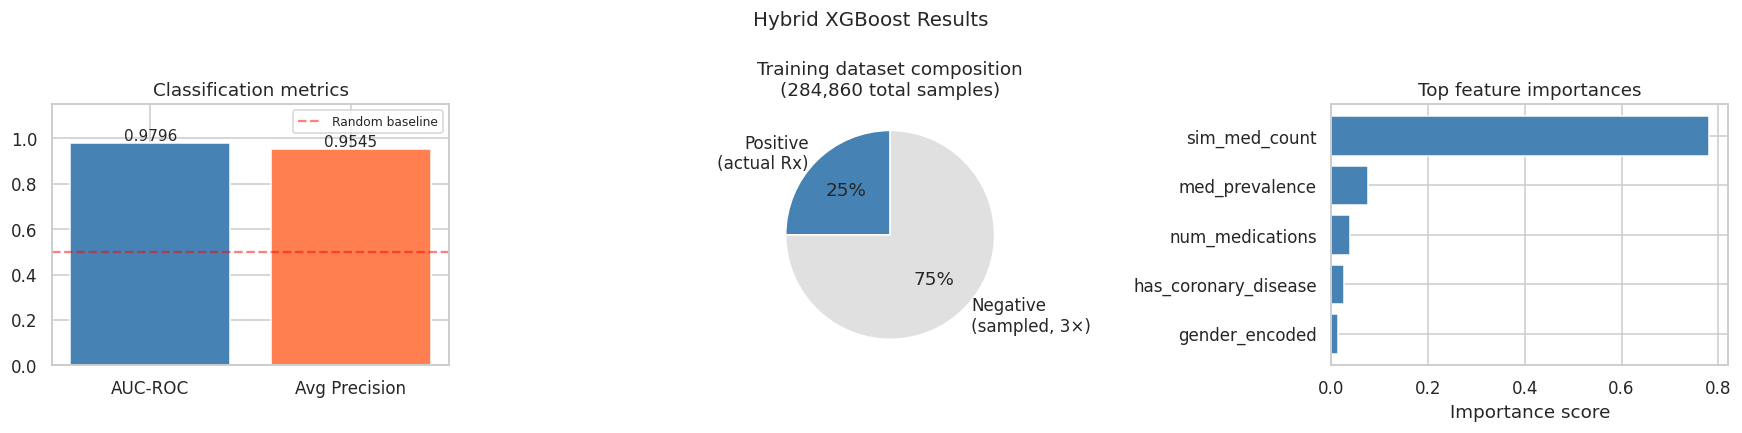

In [12]:
if xgb_run:
    auc     = xgb_run.data.metrics.get('auc_roc', 0)
    avg_p   = xgb_run.data.metrics.get('average_precision', 0)
    n_train = int(xgb_run.data.params.get('n_train', 0))
    n_test  = int(xgb_run.data.params.get('n_test',  0))
    neg_ratio = int(xgb_run.data.params.get('neg_ratio', 3))

    # Feature importances from logged metrics
    importance_metrics = {
        k.replace('importance_', ''): v
        for k, v in xgb_run.data.metrics.items()
        if k.startswith('importance_')
    }

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # AUC and Avg Precision
    bars = axes[0].bar(['AUC-ROC', 'Avg Precision'], [auc, avg_p],
                       color=['steelblue', 'coral'])
    axes[0].set_ylim(0, 1.15)
    axes[0].set_title('Classification metrics')
    axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random baseline')
    axes[0].legend(fontsize=8)
    for bar, val in zip(bars, [auc, avg_p]):
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.01,
                     f'{val:.4f}', ha='center', fontsize=10)

    # Dataset composition
    pos_n = n_train + n_test
    axes[1].pie(
        [1, neg_ratio],
        labels=[f'Positive\n(actual Rx)', f'Negative\n(sampled, {neg_ratio}×)'],
        autopct='%1.0f%%',
        colors=['steelblue', '#e0e0e0'],
        startangle=90,
    )
    axes[1].set_title(f'Training dataset composition\n({n_train+n_test:,} total samples)')

    # Feature importance
    if importance_metrics:
        imp_sorted = dict(sorted(importance_metrics.items(),
                                 key=lambda x: x[1], reverse=True))
        axes[2].barh(list(imp_sorted.keys())[::-1],
                     list(imp_sorted.values())[::-1],
                     color='steelblue')
        axes[2].set_title('Top feature importances')
        axes[2].set_xlabel('Importance score')
    else:
        axes[2].text(0.5, 0.5, 'Feature importance\nnot logged',
                     ha='center', va='center', transform=axes[2].transAxes)

    plt.suptitle('Hybrid XGBoost Results', fontsize=13)
    plt.tight_layout()
    plt.show()

## 6. Production model

In [13]:
MODEL_REGISTRY = {
    'healthcare-collaborative-filtering': 'ALS',
    'healthcare-content-based':           'Content-Based',
    'healthcare-hybrid-xgboost':          'Hybrid XGBoost',
}

print('MLflow Model Registry — all versions:')
print(f'  {"Registry name":<40} {"Version":>8}  {"Stage":<15}')
print('  ' + '-'*68)

production_model = None
for registry_name, friendly_name in MODEL_REGISTRY.items():
    try:
        versions = mlf_client.get_latest_versions(registry_name)
        for v in versions:
            stage = v.current_stage
            marker = ' ← PRODUCTION' if stage == 'Production' else ''
            print(f'  {registry_name:<40} v{v.version:>6}  {stage:<15}{marker}')
            if stage == 'Production':
                production_model = {
                    'name': registry_name,
                    'friendly': friendly_name,
                    'version': v.version,
                }
    except Exception as e:
        print(f'  {registry_name:<40} (not registered yet)')

print()
if production_model:
    print(f'Production model: {production_model["friendly"]} v{production_model["version"]}')
else:
    print('No Production model yet — run make run-evaluate')

MLflow Model Registry — all versions:
  Registry name                             Version  Stage          
  --------------------------------------------------------------------
  healthcare-collaborative-filtering       v     1  None           
  healthcare-content-based                 (not registered yet)
  healthcare-hybrid-xgboost                v     1  Production      ← PRODUCTION

Production model: Hybrid XGBoost v1


In [14]:
# Read best_model.json if it exists
import os
result_paths = [
    '../models/best_model.json',
    'models/best_model.json',
    '/opt/airflow/models/best_model.json',
]

best_model_data = None
for p in result_paths:
    if os.path.exists(p):
        with open(p) as f:
            best_model_data = json.load(f)
        print(f'Loaded best_model.json from {p}')
        break

if best_model_data:
    print()
    print('Best model result from evaluate.py:')
    for k, v in best_model_data.items():
        print(f'  {k:<20} {v}')
else:
    print('best_model.json not found locally — check models/ directory')

Loaded best_model.json from ../models/best_model.json

Best model result from evaluate.py:
  best_model           hybrid_xgboost
  registry_name        healthcare-hybrid-xgboost
  version              1
  score                0.9795566614006674


## 7. Sample recommendations

In [15]:
# Show what the recommendation target looks like:
# Top medications per condition cluster
df_sample = q("""
    SELECT
        pf.patient_id,
        pf.age,
        pf.gender_encoded,
        pf.num_conditions,
        pf.num_medications,
        pf.has_diabetes,
        pf.has_hypertension,
        pf.has_asthma
    FROM healthcare.patient_features pf
    WHERE pf.has_diabetes = 1 AND pf.has_hypertension = 1
    LIMIT 5
""")

print(f'Sample patients with Diabetes + Hypertension: {len(df_sample)}')
display(df_sample)

Sample patients with Diabetes + Hypertension: 5


,patient_id,age,gender_encoded,num_conditions,num_medications,has_diabetes,has_hypertension,has_asthma
0,00bb0d64-d7d8-d246-338e-5f0e9f426698,54,1,27,12,1,1,0
1,01238191-bd12-809e-3d23-672ddaa58617,66,1,37,14,1,1,0
2,059f527f-aef7-db62-ca94-1f783524cfd8,48,1,38,6,1,1,0
3,05c39643-5ed3-dd3c-3996-e88b67692a13,86,1,42,22,1,1,0
4,098221fc-e29c-ad49-37bd-d72dcee4ed95,46,1,34,9,1,1,0


In [16]:
# For each sample patient, show their actual medications
if len(df_sample) > 0:
    sample_pid = df_sample['patient_id'].iloc[0]
    df_actual_meds = q(f"""
        SELECT DISTINCT code, description, start_date
        FROM healthcare.medications
        WHERE patient_id = '{sample_pid}'
        ORDER BY start_date DESC
        LIMIT 15
    """)
    print(f'Actual medications for patient {sample_pid[:8]}...')
    print(f'(Diabetes + Hypertension patient, age {df_sample["age"].iloc[0]})')
    display(df_actual_meds)

Actual medications for patient 00bb0d64...
(Diabetes + Hypertension patient, age 54)


,code,description,start_date
0,314076,lisinopril 10 MG Oral Tablet,2025-11-28
1,860975,24 HR Metformin hydrochloride 500 MG Extended ...,2025-11-28
2,209387,Acetaminophen 325 MG Oral Tablet [Tylenol],2025-11-28
3,310798,Hydrochlorothiazide 25 MG Oral Tablet,2025-11-28
4,314076,lisinopril 10 MG Oral Tablet,2025-11-14
5,860975,24 HR Metformin hydrochloride 500 MG Extended ...,2025-11-14
6,209387,Acetaminophen 325 MG Oral Tablet [Tylenol],2025-11-14
7,310798,Hydrochlorothiazide 25 MG Oral Tablet,2025-11-14
8,314076,lisinopril 10 MG Oral Tablet,2025-11-07
9,860975,24 HR Metformin hydrochloride 500 MG Extended ...,2025-11-07


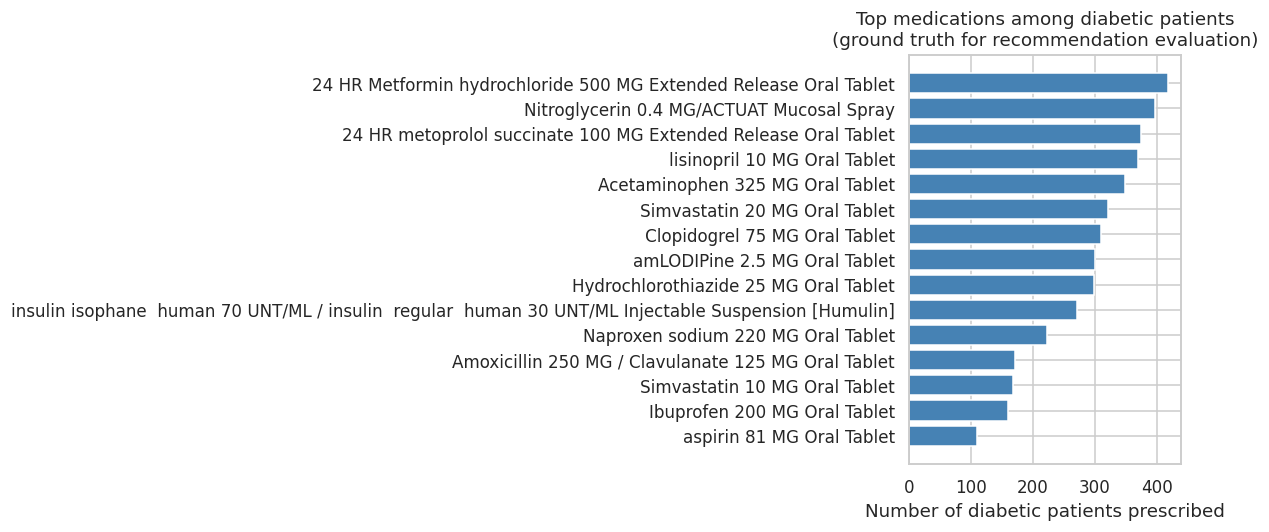

,description,patient_count
0,24 HR Metformin hydrochloride 500 MG Extended ...,419
1,Nitroglycerin 0.4 MG/ACTUAT Mucosal Spray,397
2,24 HR metoprolol succinate 100 MG Extended Rel...,375
3,lisinopril 10 MG Oral Tablet,370
4,Acetaminophen 325 MG Oral Tablet,349
5,Simvastatin 20 MG Oral Tablet,321
6,Clopidogrel 75 MG Oral Tablet,310
7,amLODIPine 2.5 MG Oral Tablet,301
8,Hydrochlorothiazide 25 MG Oral Tablet,299
9,insulin isophane human 70 UNT/ML / insulin r...,271


In [17]:
# Most commonly recommended medications for diabetic patients
df_diabetic_meds = q("""
    SELECT
        m.description,
        count(DISTINCT m.patient_id) AS patient_count
    FROM healthcare.medications m
    INNER JOIN healthcare.conditions c
        ON m.patient_id = c.patient_id
        AND c.code IN ('44054006', '73211009')
    GROUP BY m.description
    ORDER BY patient_count DESC
    LIMIT 15
""")

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(df_diabetic_meds['description'][::-1],
        df_diabetic_meds['patient_count'][::-1],
        color='steelblue')
ax.set_xlabel('Number of diabetic patients prescribed')
ax.set_title('Top medications among diabetic patients\n(ground truth for recommendation evaluation)')
plt.tight_layout()
plt.show()

df_diabetic_meds.head(10)

## 8. Model training summary

In [18]:
print('=' * 65)
print('MODEL TRAINING SUMMARY — Milestone 3')
print('=' * 65)

model_labels = {
    'collaborative_filtering':        'ALS Collaborative Filtering',
    'content_based_cosine_similarity':'Content-Based (Cosine Similarity)',
    'hybrid_xgboost':                 'Hybrid XGBoost Classifier',
}

for key, run in latest_runs.items():
    label   = model_labels.get(key, key)
    metrics = run.data.metrics
    print(f'\n  {label}')
    print(f'  Run ID: {run.info.run_id[:16]}...')

    if 'rmse' in metrics:
        print(f'    RMSE:            {metrics["rmse"]:.4f}')
    if 'precision_at_k' in metrics:
        print(f'    Precision@10:    {metrics["precision_at_k"]:.4f}')
    if 'recall_at_k' in metrics:
        print(f'    Recall@10:       {metrics["recall_at_k"]:.4f}')
    if 'ndcg_at_k' in metrics:
        print(f'    NDCG@10:         {metrics["ndcg_at_k"]:.4f}')
    if 'auc_roc' in metrics:
        print(f'    AUC-ROC:         {metrics["auc_roc"]:.4f}')
    if 'average_precision' in metrics:
        print(f'    Avg Precision:   {metrics["average_precision"]:.4f}')

print()
if production_model:
    print(f'  Production model: {production_model["friendly"]} v{production_model["version"]}')
print()
print('  Next: Milestone 4 — Flask API + Streamlit dashboard')
print('=' * 65)

MODEL TRAINING SUMMARY — Milestone 3

  ALS Collaborative Filtering
  Run ID: b2c5500afc494d29...

  Hybrid XGBoost Classifier
  Run ID: 57af36fab12141fb...
    AUC-ROC:         0.9796
    Avg Precision:   0.9545

  Content-Based (Cosine Similarity)
  Run ID: 769903947ea94734...
    Precision@10:    0.0000
    Recall@10:       0.0000
    NDCG@10:         0.0000

  Production model: Hybrid XGBoost v1

  Next: Milestone 4 — Flask API + Streamlit dashboard
